## 实验目的

1. 掌握逻辑回归模型的数学原理与实现方法  
2. 理解 Softmax 回归在多分类问题中的应用  
3. 学会使用梯度下降算法优化分类模型  
4. 掌握分类模型的评估指标与结果分析方法  
5. 能够应用逻辑回归和 Softmax 模型解决实际问题（如手写数字识别）

In [13]:
#使用MNIST手写数字数据集：
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 加载数据集
digits = load_digits()
X, y = digits.data, digits.target

# 数据预处理
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 划分数据集
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

In [14]:
import numpy as np
#逻辑回归实现（二分类）
class LogisticRegression:
    def __init__(self, learning_rate: float = 0.01, n_iters: int = 1000):
        self.lr = learning_rate
        #初始化参数
        self.n_iters = n_iters
        self.weights = None
        self.bias = None
        self.loss_history = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X: np.ndarray, y: np.ndarray):
        n_samples, n_features = X.shape
        #初始化参数
        self.weights = np.zeros(n_features)
        self.bias = 0
        #梯度下降
        for _ in range(self.n_iters):
            #前向传播
            linear_model = np.dot(X, self.weights) + self.bias
            y_pred = self.sigmoid(linear_model)

            # 防止log(0)导致的数值问题,计算损失
            y_pred = np.clip(y_pred, 1e-8, 1 - 1e-8)
            loss = -np.mean(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))
            self.loss_history.append(loss)
            #反向传播
            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)
            #update 
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict(self, X: np.ndarray, threshold: float = 0.5):
        linear_model = np.dot(X, self.weights) + self.bias
        y_pred = self.sigmoid(linear_model)
        return (y_pred >= threshold).astype(int)


In [15]:
# Softmax回归实现（多分类）
class SoftmaxRegression:
    def __init__(self, learning_rate=0.01, n_iters=1000, lambda_=0.01):
        self.lr = learning_rate
        self.n_iters = n_iters
        self.lambda_ = lambda_  # L2正则化系数
        self.theta = None
        self.loss_history = []

    def softmax(self, z):
        # 数值稳定性处理
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.classes_ = np.unique(y)
        n_classes = len(self.classes_)

        # 初始化参数矩阵 (n_features x n_classes)
        self.theta = np.zeros((n_features, n_classes))

        # 将标签转换为one-hot编码
        y_onehot = np.eye(n_classes)[y]

        for i in range(self.n_iters):
            # 前向传播
            scores = np.dot(X, self.theta)
            probs = self.softmax(scores)

            # 计算损失（含L2正则化）
            data_loss = -np.mean(np.sum(y_onehot * np.log(probs + 1e-10), axis=1))
            reg_loss = 0.5 * self.lambda_ * np.sum(self.theta * self.theta)
            loss = data_loss + reg_loss
            self.loss_history.append(loss)

            # 反向传播
            gradient = (1 / n_samples) * np.dot(X.T, (probs - y_onehot))
            gradient += self.lambda_ * self.theta  # L2正则化梯度

            # 更新参数
            self.theta -= self.lr * gradient

    def predict(self, X):
        scores = np.dot(X, self.theta)
        probs = self.softmax(scores)
        return np.argmax(probs, axis=1)

In [16]:
# 模型评估
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(model, X_test, y_test):
    # 预测
    y_pred = model.predict(X_test)
    # 计算准确率
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.4f}")
    # 混淆矩阵
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()
    # 分类报告
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    # 损失曲线
    if hasattr(model, 'loss_history'):
        plt.figure(figsize=(10, 6))
        plt.plot(model.loss_history)
        plt.xlabel('Iterations')
        plt.ylabel('Loss')
        plt.title('Training Loss History')
        plt.grid(True)
        plt.show()

Accuracy: 0.9639


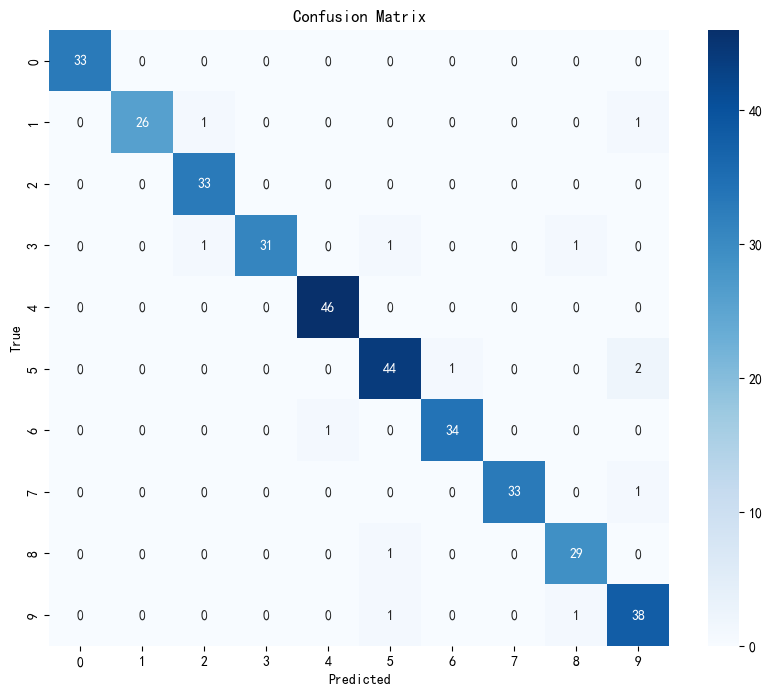


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      0.93      0.96        28
           2       0.94      1.00      0.97        33
           3       1.00      0.91      0.95        34
           4       0.98      1.00      0.99        46
           5       0.94      0.94      0.94        47
           6       0.97      0.97      0.97        35
           7       1.00      0.97      0.99        34
           8       0.94      0.97      0.95        30
           9       0.90      0.95      0.93        40

    accuracy                           0.96       360
   macro avg       0.97      0.96      0.96       360
weighted avg       0.96      0.96      0.96       360



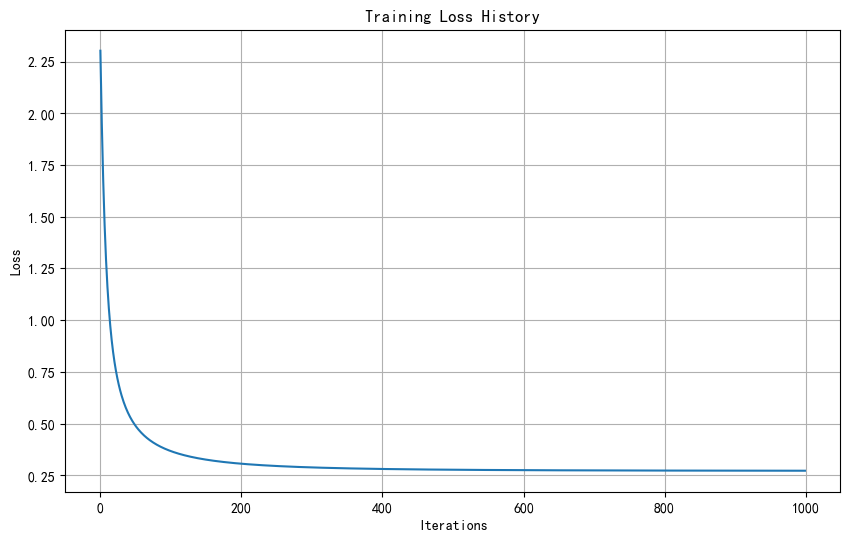

In [17]:
# 实验执行（以Softmax回归为例）
# 创建并训练模型
model = SoftmaxRegression(learning_rate=0.1, n_iters=1000, lambda_=0.01)
model.fit(X_train, y_train)

# 评估模型
evaluate_model(model, X_test, y_test)


1. **逻辑回归实现与测试**  
    - 使用逻辑回归模型解决二分类问题（如识别数字是否为“0”）  
    - 实现并分析不同学习率（0.001、0.01、0.1）对训练过程的影响  
    - 绘制损失函数下降曲线和决策边界  

2. **Softmax回归实现与测试**  
    - 使用Softmax回归模型解决MNIST多分类问题  
    - 实现L2正则化，并分析不同正则化强度（0、0.01、0.1、1）对模型性能的影响  
    - 可视化混淆矩阵并分析分类错误模式  

3. **模型对比分析**  
    - 比较逻辑回归和Softmax回归在相同任务上的表现  
    - 分析两种模型的训练时间、收敛速度和最终精度差异  

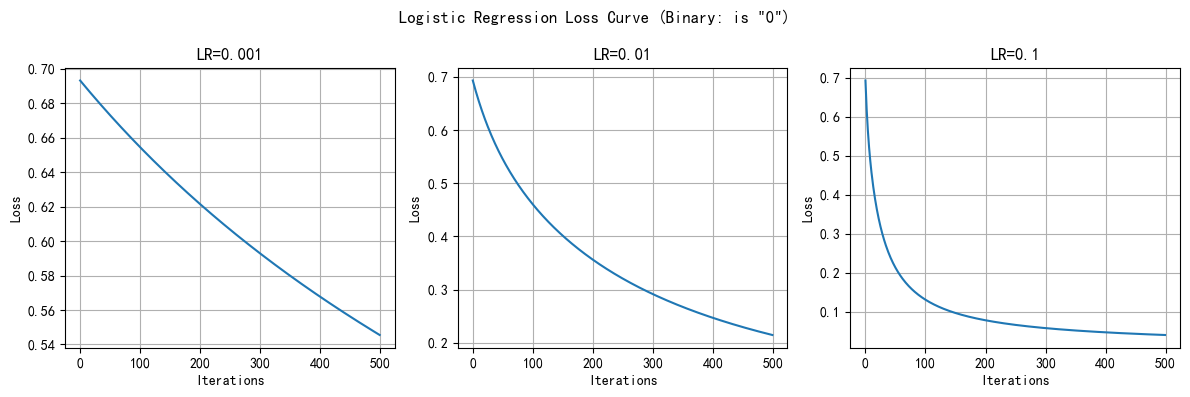


Logistic Regression (learning_rate=0.001):
Accuracy: 0.8111


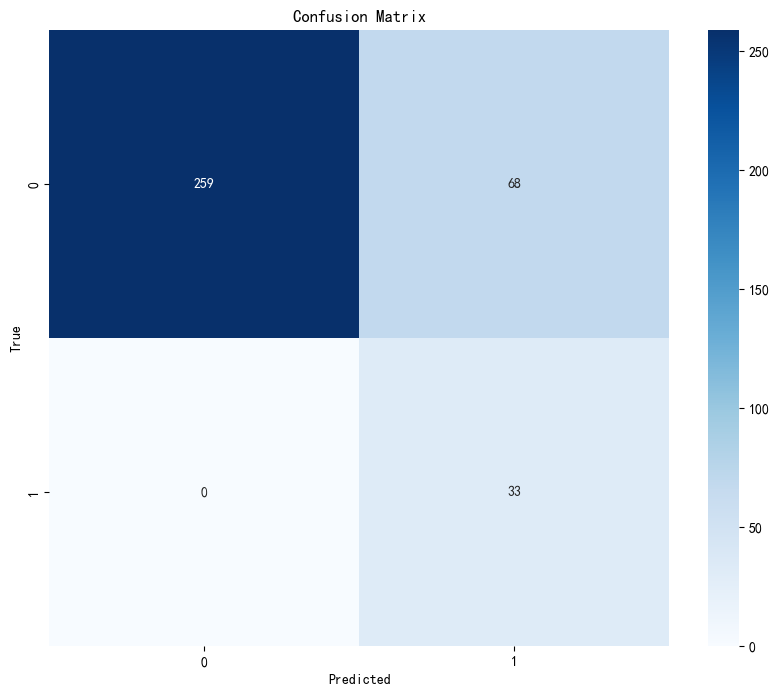


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.79      0.88       327
           1       0.33      1.00      0.49        33

    accuracy                           0.81       360
   macro avg       0.66      0.90      0.69       360
weighted avg       0.94      0.81      0.85       360



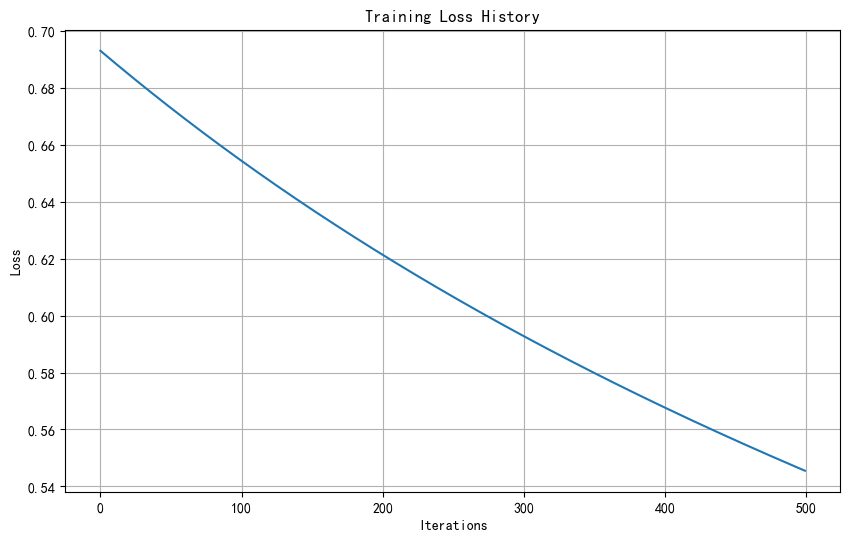


Logistic Regression (learning_rate=0.01):
Accuracy: 0.9861


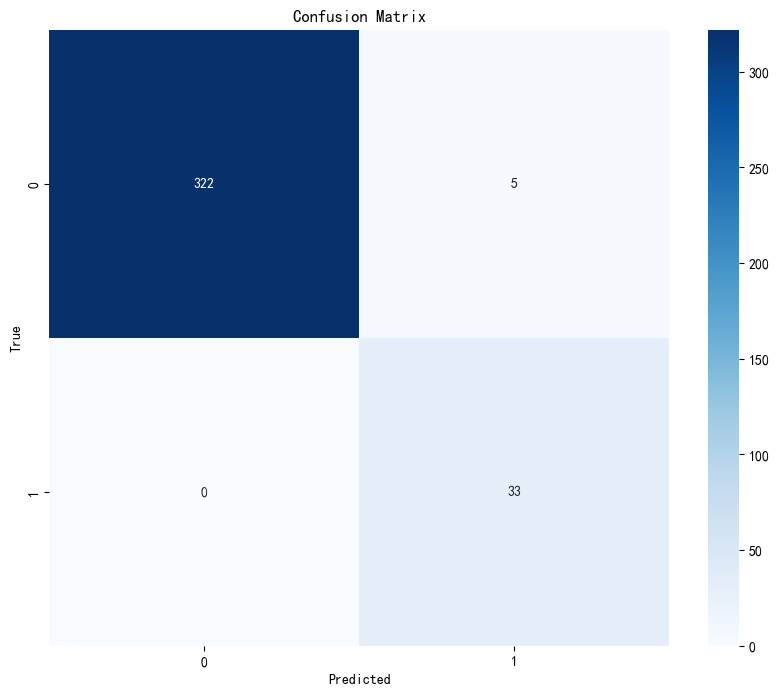


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       327
           1       0.87      1.00      0.93        33

    accuracy                           0.99       360
   macro avg       0.93      0.99      0.96       360
weighted avg       0.99      0.99      0.99       360



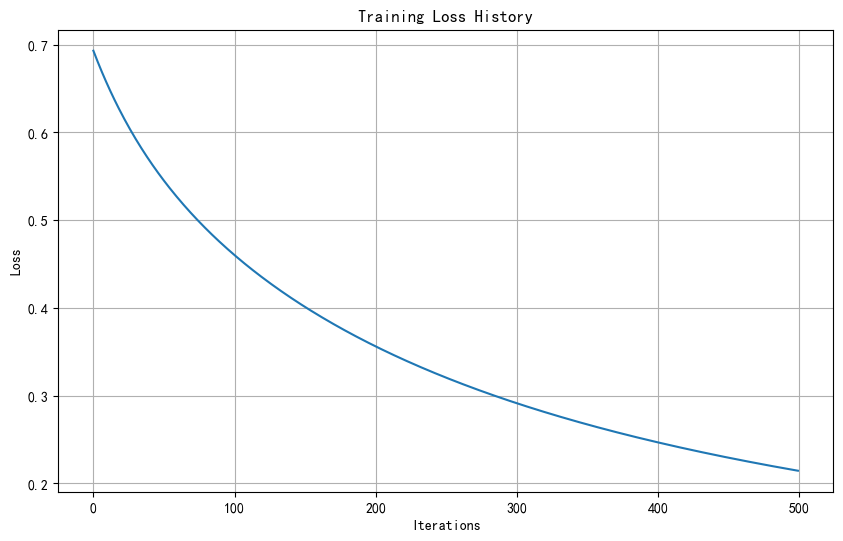


Logistic Regression (learning_rate=0.1):
Accuracy: 0.9972


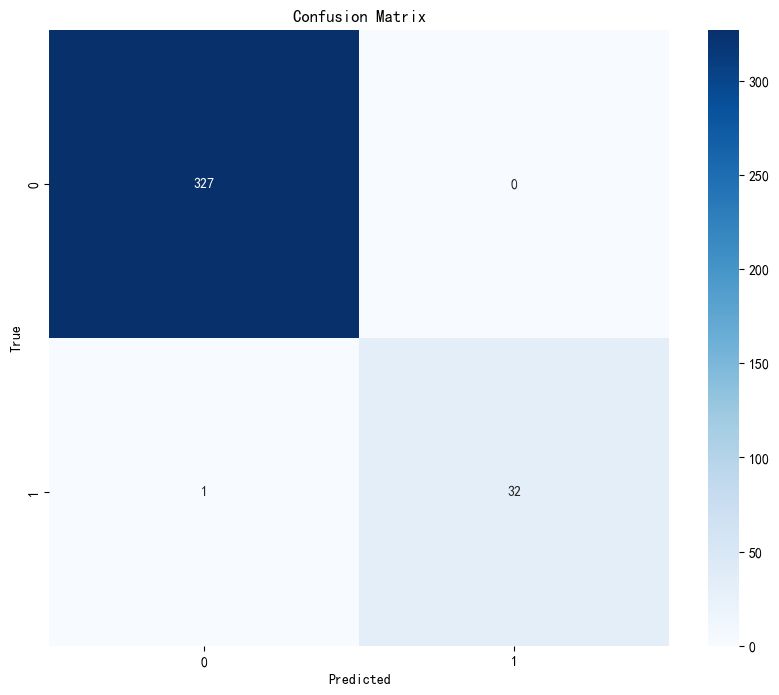


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       327
           1       1.00      0.97      0.98        33

    accuracy                           1.00       360
   macro avg       1.00      0.98      0.99       360
weighted avg       1.00      1.00      1.00       360



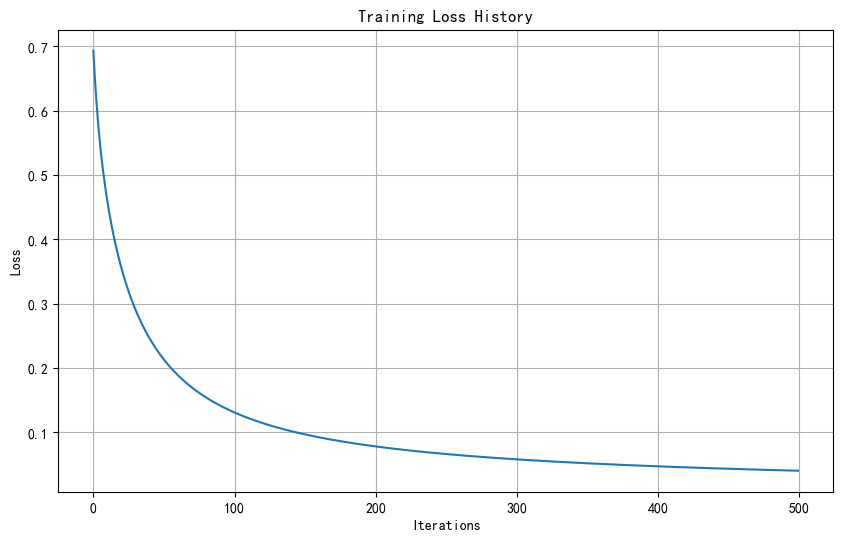

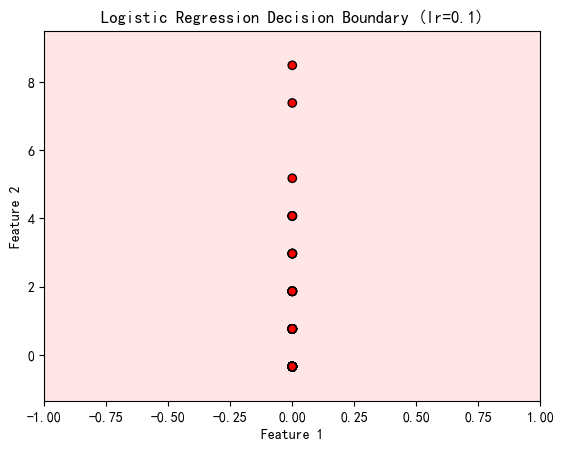

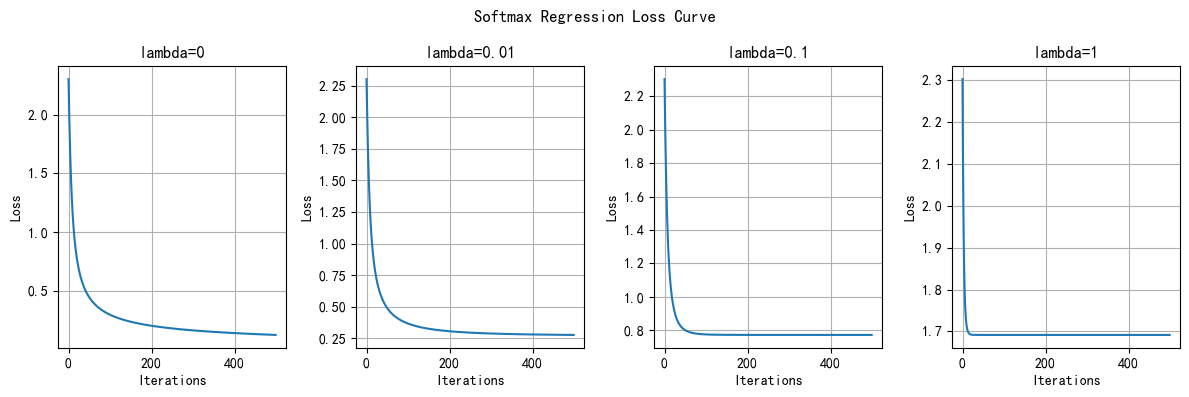


Softmax Regression (lambda=0):
Accuracy: 0.9639


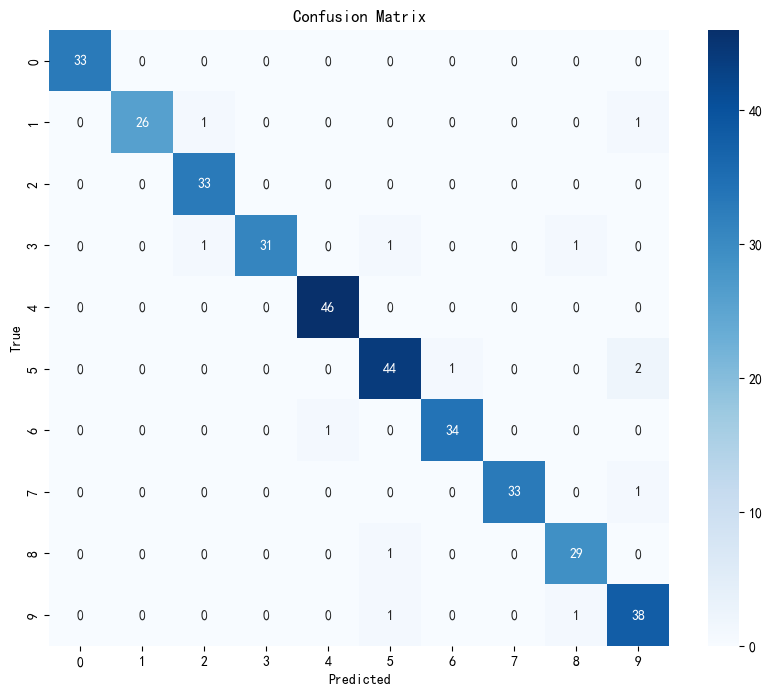


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      0.93      0.96        28
           2       0.94      1.00      0.97        33
           3       1.00      0.91      0.95        34
           4       0.98      1.00      0.99        46
           5       0.94      0.94      0.94        47
           6       0.97      0.97      0.97        35
           7       1.00      0.97      0.99        34
           8       0.94      0.97      0.95        30
           9       0.90      0.95      0.93        40

    accuracy                           0.96       360
   macro avg       0.97      0.96      0.96       360
weighted avg       0.96      0.96      0.96       360



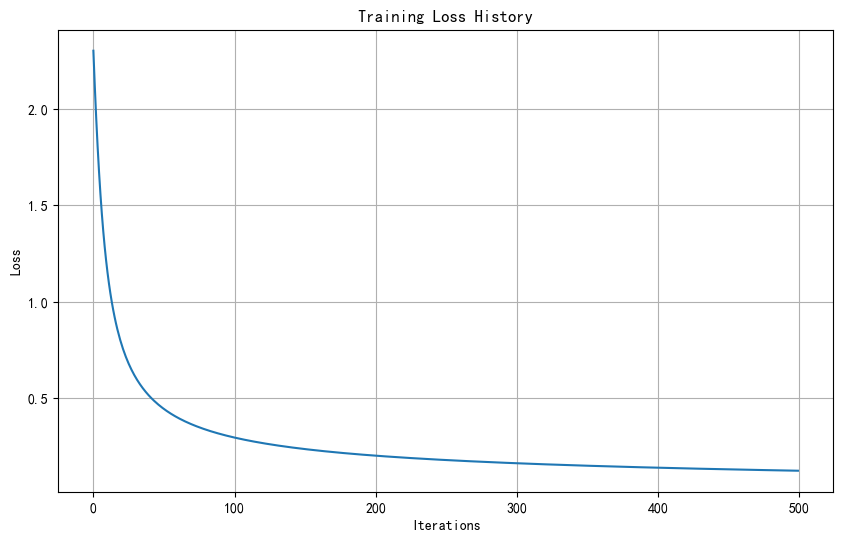

<Figure size 800x600 with 0 Axes>

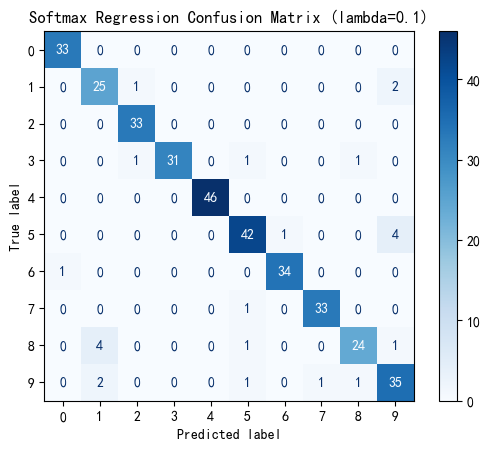

分类错误最多的类别对：
真实类别 5 最容易被误分为 9，次数：4

Softmax Regression (lambda=0.01):
Accuracy: 0.9583


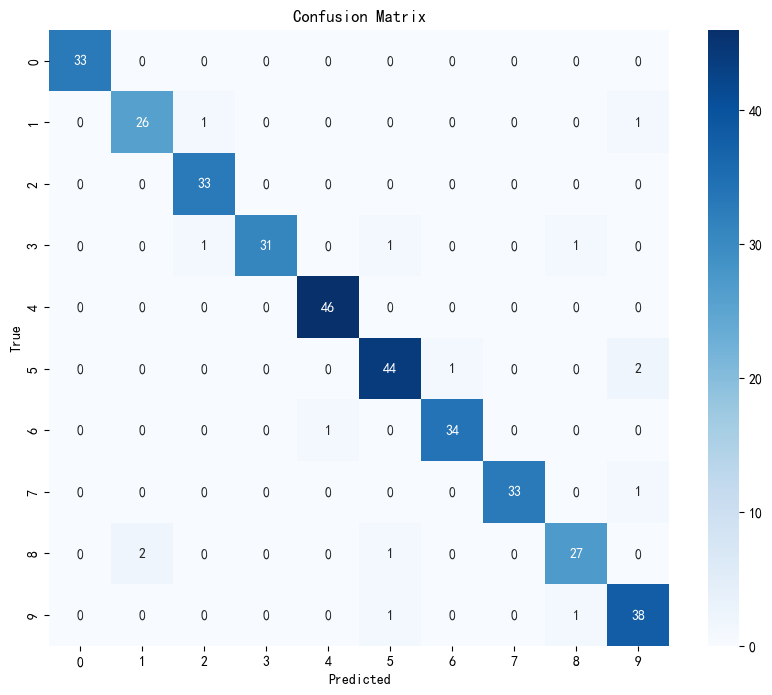


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       0.93      0.93      0.93        28
           2       0.94      1.00      0.97        33
           3       1.00      0.91      0.95        34
           4       0.98      1.00      0.99        46
           5       0.94      0.94      0.94        47
           6       0.97      0.97      0.97        35
           7       1.00      0.97      0.99        34
           8       0.93      0.90      0.92        30
           9       0.90      0.95      0.93        40

    accuracy                           0.96       360
   macro avg       0.96      0.96      0.96       360
weighted avg       0.96      0.96      0.96       360



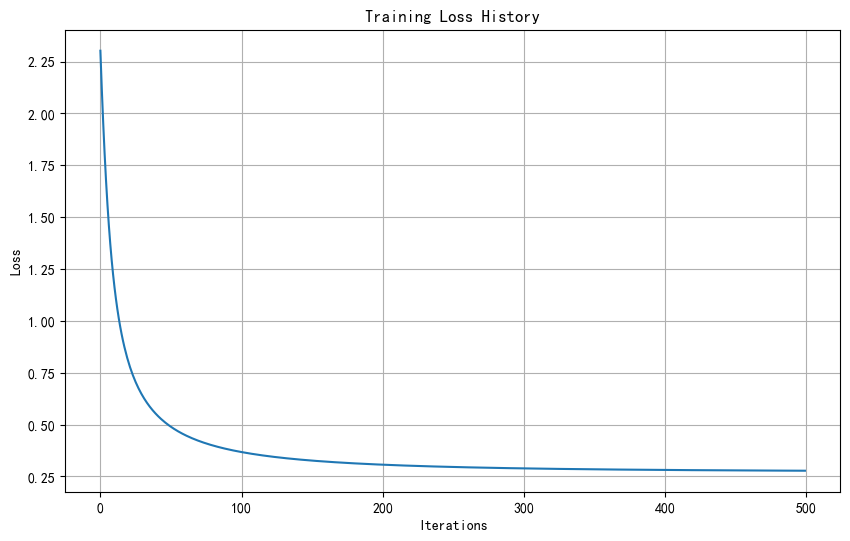

<Figure size 800x600 with 0 Axes>

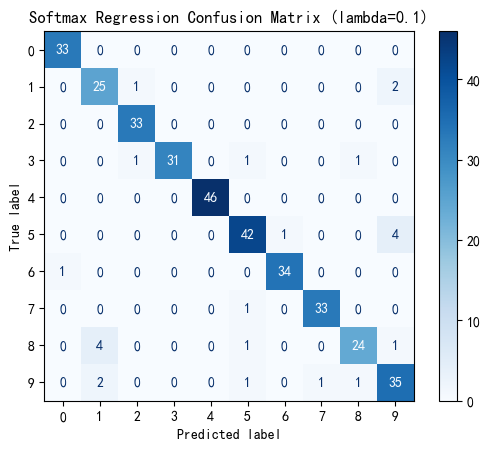

分类错误最多的类别对：
真实类别 5 最容易被误分为 9，次数：4

Softmax Regression (lambda=0.1):
Accuracy: 0.9333


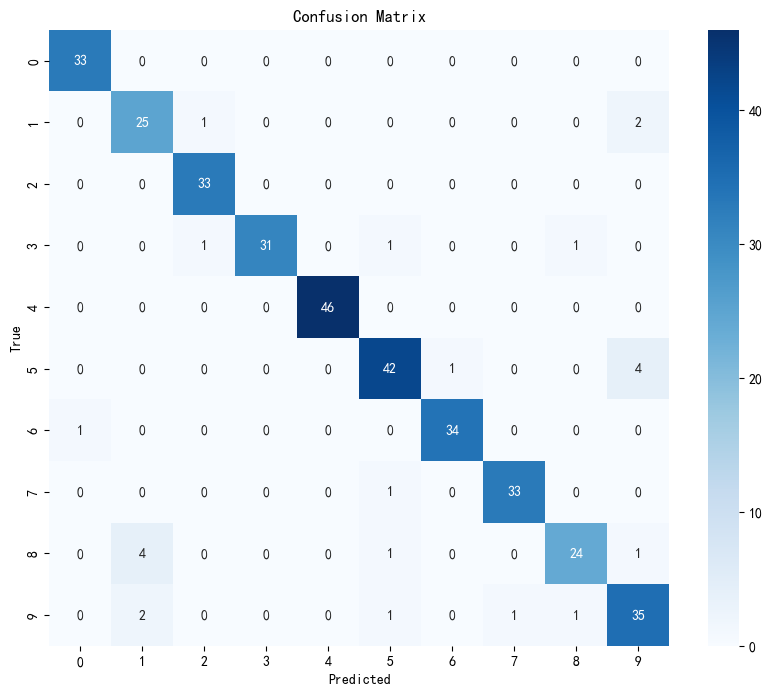


Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        33
           1       0.81      0.89      0.85        28
           2       0.94      1.00      0.97        33
           3       1.00      0.91      0.95        34
           4       1.00      1.00      1.00        46
           5       0.91      0.89      0.90        47
           6       0.97      0.97      0.97        35
           7       0.97      0.97      0.97        34
           8       0.92      0.80      0.86        30
           9       0.83      0.88      0.85        40

    accuracy                           0.93       360
   macro avg       0.93      0.93      0.93       360
weighted avg       0.94      0.93      0.93       360



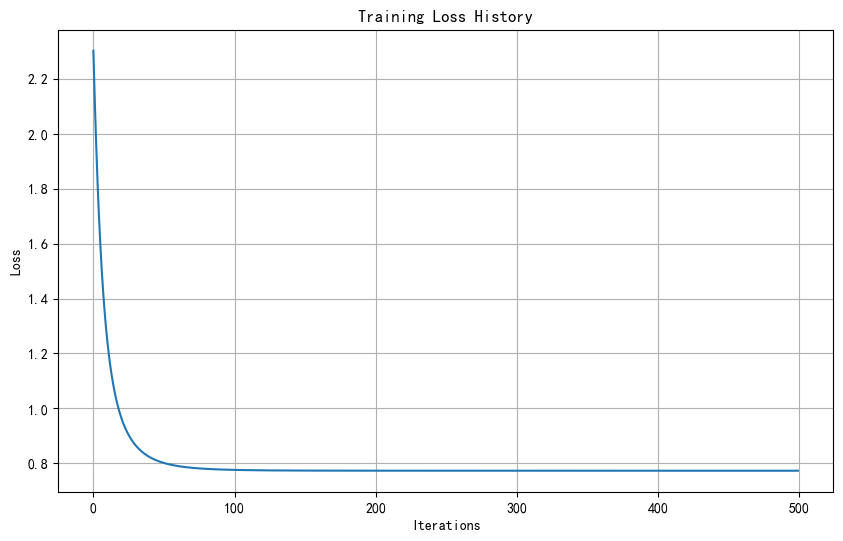

<Figure size 800x600 with 0 Axes>

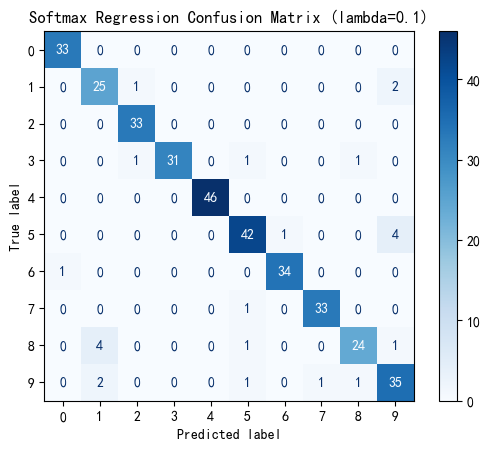

分类错误最多的类别对：
真实类别 5 最容易被误分为 9，次数：4

Softmax Regression (lambda=1):
Accuracy: 0.8833


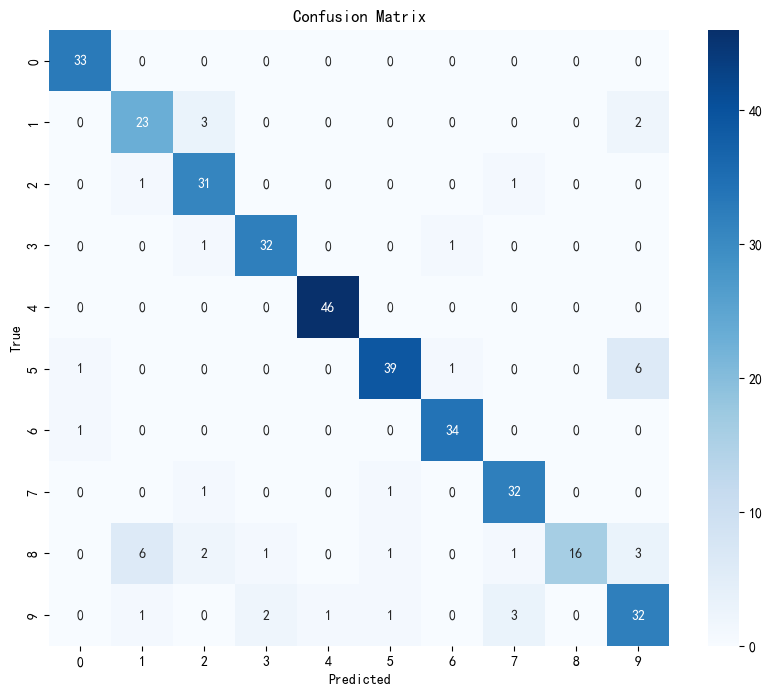


Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        33
           1       0.74      0.82      0.78        28
           2       0.82      0.94      0.87        33
           3       0.91      0.94      0.93        34
           4       0.98      1.00      0.99        46
           5       0.93      0.83      0.88        47
           6       0.94      0.97      0.96        35
           7       0.86      0.94      0.90        34
           8       1.00      0.53      0.70        30
           9       0.74      0.80      0.77        40

    accuracy                           0.88       360
   macro avg       0.89      0.88      0.87       360
weighted avg       0.89      0.88      0.88       360



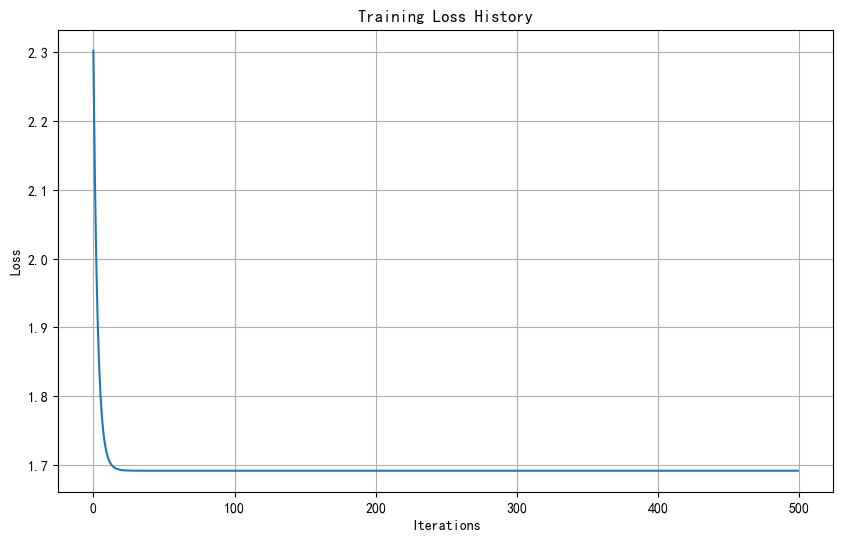

<Figure size 800x600 with 0 Axes>

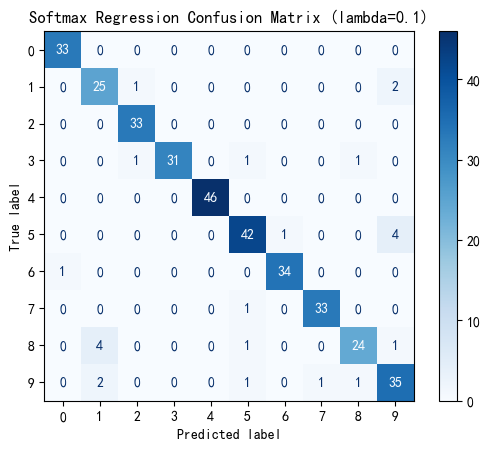

分类错误最多的类别对：
真实类别 5 最容易被误分为 9，次数：4

模型训练时间对比：
Logistic Regression (lr=0.001): 0.0541 s
Logistic Regression (lr=0.01): 0.0581 s
Logistic Regression (lr=0.1): 0.0622 s
Softmax Regression (lambda=0): 0.2791 s
Softmax Regression (lambda=0.01): 0.2538 s
Softmax Regression (lambda=0.1): 0.2619 s
Softmax Regression (lambda=1): 0.2273 s

模型最终精度对比：
Logistic Regression (lr=0.001): Accuracy=0.8111
Logistic Regression (lr=0.01): Accuracy=0.9861
Logistic Regression (lr=0.1): Accuracy=0.9972
Softmax Regression (lambda=0): Accuracy=0.9639
Softmax Regression (lambda=0.01): Accuracy=0.9583
Softmax Regression (lambda=0.1): Accuracy=0.9333
Softmax Regression (lambda=1): Accuracy=0.8833

收敛速度可通过损失曲线对比（见上图）


In [18]:
from matplotlib.colors import ListedColormap
import time
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. 逻辑回归实现与测试（二分类：识别数字是否为"0"）

# 构造二分类标签：是0为1，非0为0
y_train_bin = (y_train == 0).astype(int)
y_test_bin = (y_test == 0).astype(int)

learning_rates = [0.001, 0.01, 0.1]
logreg_models = []
plt.figure(figsize=(12, 4))

for i, lr in enumerate(learning_rates):
    # 创建并训练逻辑回归模型
    logreg = LogisticRegression(learning_rate=lr, n_iters=500)
    logreg.fit(X_train, y_train_bin)
    logreg_models.append(logreg)
    
    # 绘制损失曲线
    plt.subplot(1, 3, i+1)
    plt.plot(logreg.loss_history)
    plt.title(f'LR={lr}')
    plt.xlabel('Iterations')
    plt.ylabel('Loss')
    plt.grid(True)
plt.suptitle('Logistic Regression Loss Curve (Binary: is "0")')
plt.tight_layout()
plt.show()

# 评估不同学习率下的模型
for lr, model in zip(learning_rates, logreg_models):
    print(f"\nLogistic Regression (learning_rate={lr}):")
    evaluate_model(model, X_test, y_test_bin)

# 绘制决策边界（仅选取前两维特征做可视化）

def plot_decision_boundary(model, X, y, title):
    X_vis = X[:, :2]
    x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
    y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    X_grid = np.c_[xx.ravel(), yy.ravel()]
    # 只用前两维特征，补零到64维
    X_full = np.zeros((X_grid.shape[0], X.shape[1]))
    X_full[:, :2] = X_grid
    Z = model.predict(X_full)
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(['#FFAAAA', '#AAAAFF']))
    plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y, edgecolor='k', cmap=ListedColormap(['red', 'blue']))
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

# 可视化决策边界（以学习率0.1为例）
plot_decision_boundary(logreg_models[2], X_test, y_test_bin, 'Logistic Regression Decision Boundary (lr=0.1)')

# 2. Softmax回归实现与测试（多分类）

# 不同L2正则化强度
lambdas = [0, 0.01, 0.1, 1]
softmax_models = []
plt.figure(figsize=(12, 4))

for i, lam in enumerate(lambdas):
    # 创建并训练Softmax回归模型
    softmax = SoftmaxRegression(learning_rate=0.1, n_iters=500, lambda_=lam)
    softmax.fit(X_train, y_train)
    softmax_models.append(softmax)
    
    # 绘制损失曲线
    plt.subplot(1, 4, i+1)
    plt.plot(softmax.loss_history)
    plt.title(f'lambda={lam}')
    plt.xlabel('Iterations')
    plt.ylabel('Loss')
    plt.grid(True)
plt.suptitle('Softmax Regression Loss Curve')
plt.tight_layout()
plt.show()

# 评估不同正则化强度下的模型
for lam, model in zip(lambdas, softmax_models):
    print(f"\nSoftmax Regression (lambda={lam}):")
    evaluate_model(model, X_test, y_test)
    # 以lambda=0.1为例，绘制混淆矩阵
    best_softmax = softmax_models[2]  # lambda=0.1
    y_pred = best_softmax.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=digits.target_names)
    plt.figure(figsize=(8, 6))
    disp.plot(cmap='Blues', values_format='d')
    plt.title('Softmax Regression Confusion Matrix (lambda=0.1)')
    plt.show()

    # 简要分析分类错误模式
    print("分类错误最多的类别对：")
    # 排除对角线，仅分析错误
    cm_offdiag = cm.copy()
    np.fill_diagonal(cm_offdiag, 0)
    max_idx = np.unravel_index(np.argmax(cm_offdiag), cm_offdiag.shape)
    print(f"真实类别 {max_idx[0]} 最容易被误分为 {max_idx[1]}，次数：{cm_offdiag[max_idx]}")
# 3. 模型对比分析


# 记录训练时间
print("\n模型训练时间对比：")
for lr in learning_rates:
    logreg = LogisticRegression(learning_rate=lr, n_iters=500)
    start = time.time()
    logreg.fit(X_train, y_train_bin)
    end = time.time()
    print(f"Logistic Regression (lr={lr}): {end - start:.4f} s")

for lam in lambdas:
    softmax = SoftmaxRegression(learning_rate=0.1, n_iters=500, lambda_=lam)
    start = time.time()
    softmax.fit(X_train, y_train)
    end = time.time()
    print(f"Softmax Regression (lambda={lam}): {end - start:.4f} s")

print("\n模型最终精度对比：")
for lr, model in zip(learning_rates, logreg_models):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test_bin, y_pred)
    print(f"Logistic Regression (lr={lr}): Accuracy={acc:.4f}")

for lam, model in zip(lambdas, softmax_models):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Softmax Regression (lambda={lam}): Accuracy={acc:.4f}")

print("\n收敛速度可通过损失曲线对比（见上图）")

1. **高级优化算法**  
    - 实现并比较不同优化器（SGD, Adam）的性能  
    - 添加学习率衰减策略并分析效果  

2. **特征工程实验**  
    - 尝试不同的特征缩放方法（标准化、归一化）  
    - 使用PCA降维并分析对模型性能的影响  

3. **多模型对比**  
    - 使用 scikit-learn 的 LogisticRegression 实现多分类  
    - 比较自实现模型与 scikit-learn 实现的性能差异  
    - 尝试其他分类算法（如 SVM、随机森林）并与逻辑回归类模型对比  

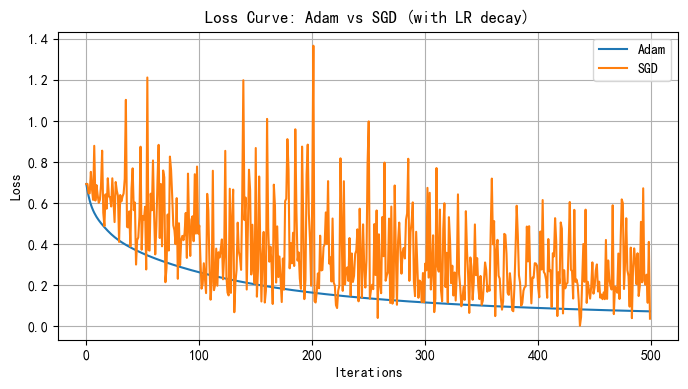

Adam Optimizer:
Accuracy: 0.9944


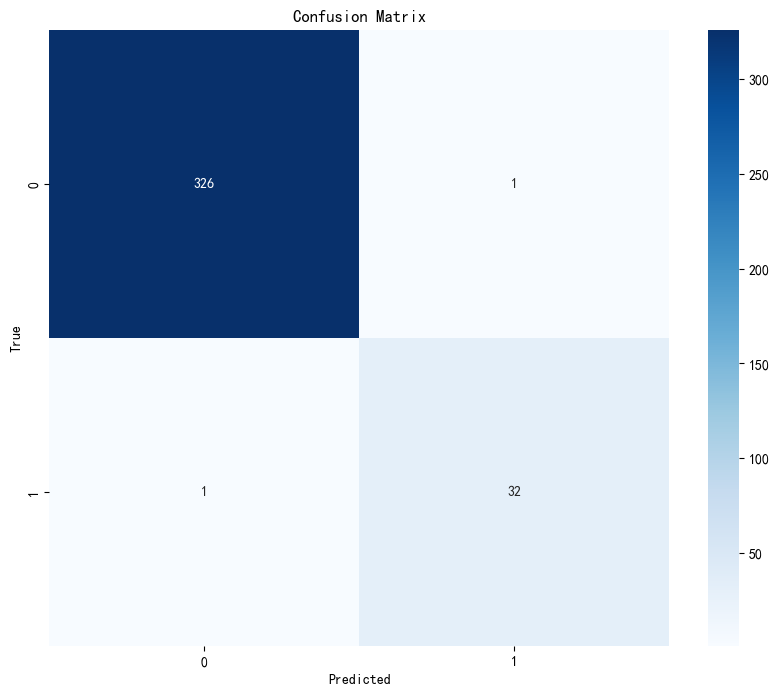


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       327
           1       0.97      0.97      0.97        33

    accuracy                           0.99       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.99      0.99      0.99       360



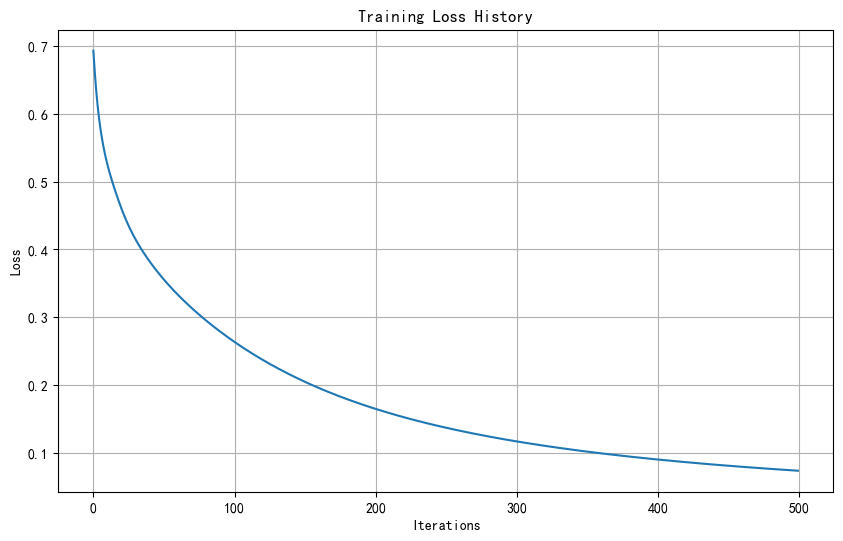

SGD Optimizer:
Accuracy: 0.9833


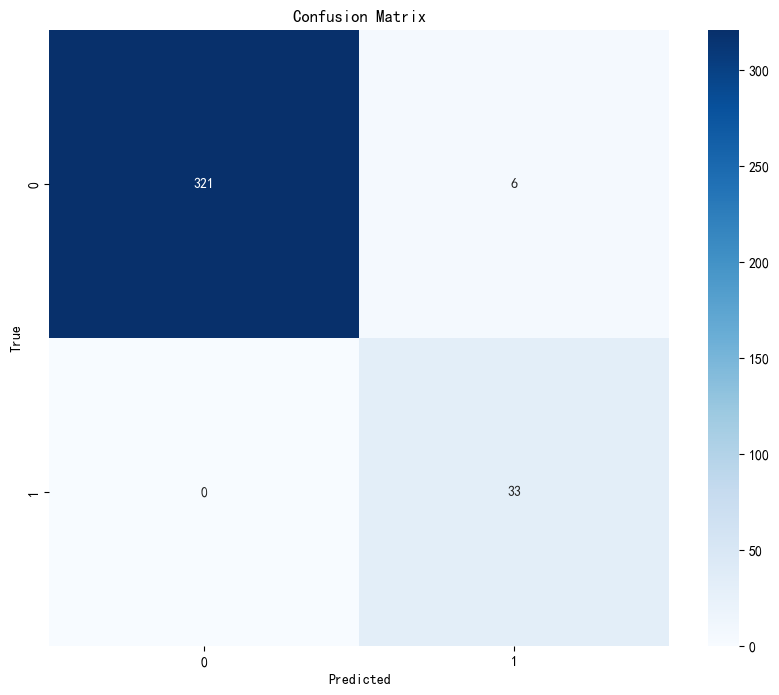


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       327
           1       0.85      1.00      0.92        33

    accuracy                           0.98       360
   macro avg       0.92      0.99      0.95       360
weighted avg       0.99      0.98      0.98       360



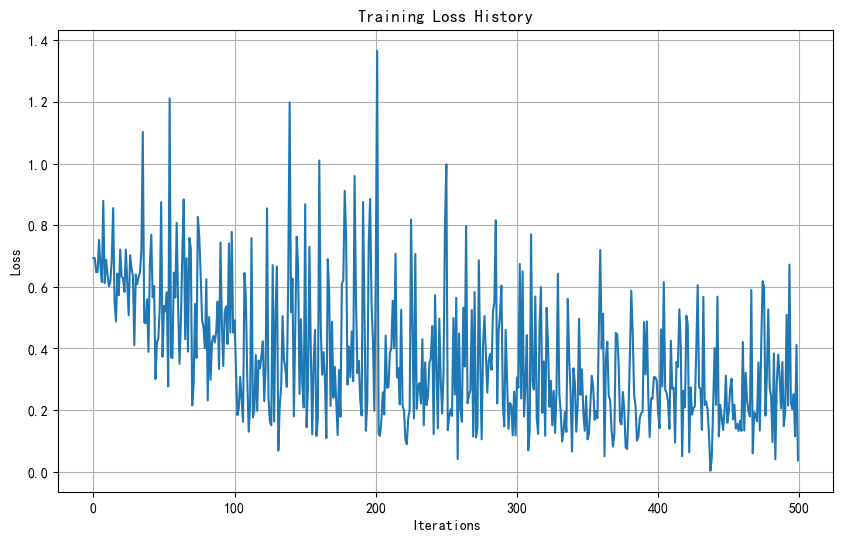

Softmax Regression with PCA (20 dims):
Accuracy: 0.9194


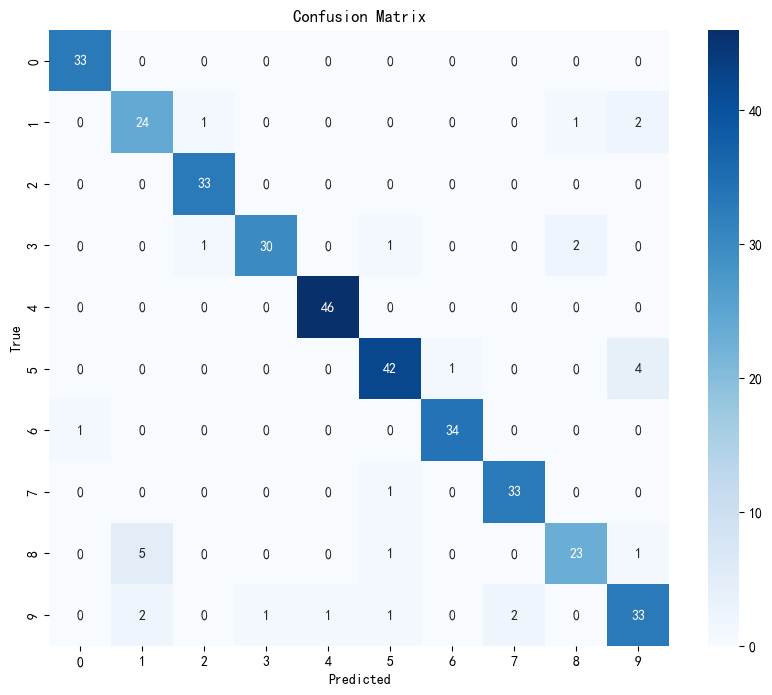


Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        33
           1       0.77      0.86      0.81        28
           2       0.94      1.00      0.97        33
           3       0.97      0.88      0.92        34
           4       0.98      1.00      0.99        46
           5       0.91      0.89      0.90        47
           6       0.97      0.97      0.97        35
           7       0.94      0.97      0.96        34
           8       0.88      0.77      0.82        30
           9       0.82      0.82      0.82        40

    accuracy                           0.92       360
   macro avg       0.92      0.92      0.92       360
weighted avg       0.92      0.92      0.92       360



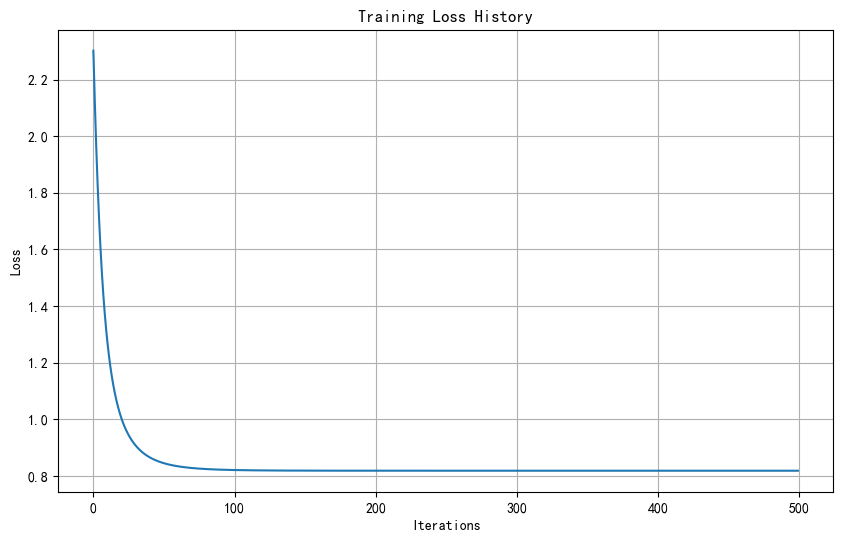

Softmax Regression with MinMax Scaling:
Accuracy: 0.8972


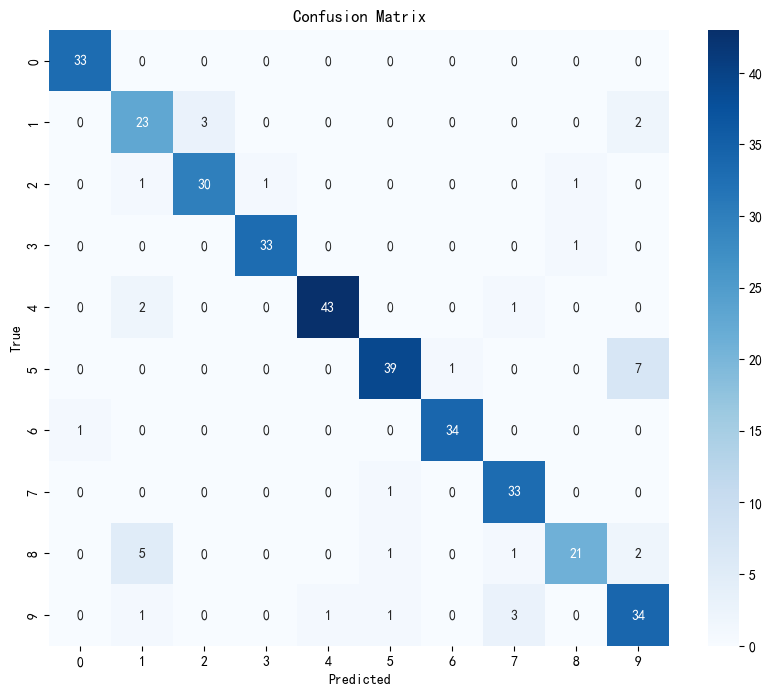


Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        33
           1       0.72      0.82      0.77        28
           2       0.91      0.91      0.91        33
           3       0.97      0.97      0.97        34
           4       0.98      0.93      0.96        46
           5       0.93      0.83      0.88        47
           6       0.97      0.97      0.97        35
           7       0.87      0.97      0.92        34
           8       0.91      0.70      0.79        30
           9       0.76      0.85      0.80        40

    accuracy                           0.90       360
   macro avg       0.90      0.90      0.89       360
weighted avg       0.90      0.90      0.90       360



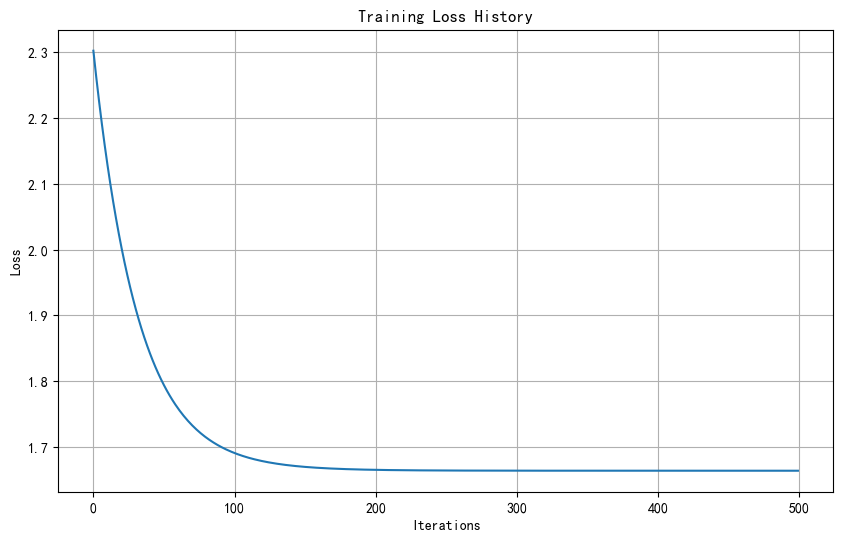

scikit-learn LogisticRegression:
Accuracy: 0.9722


d:\software\Miniconda\miniconda3\envs\machine_learning\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


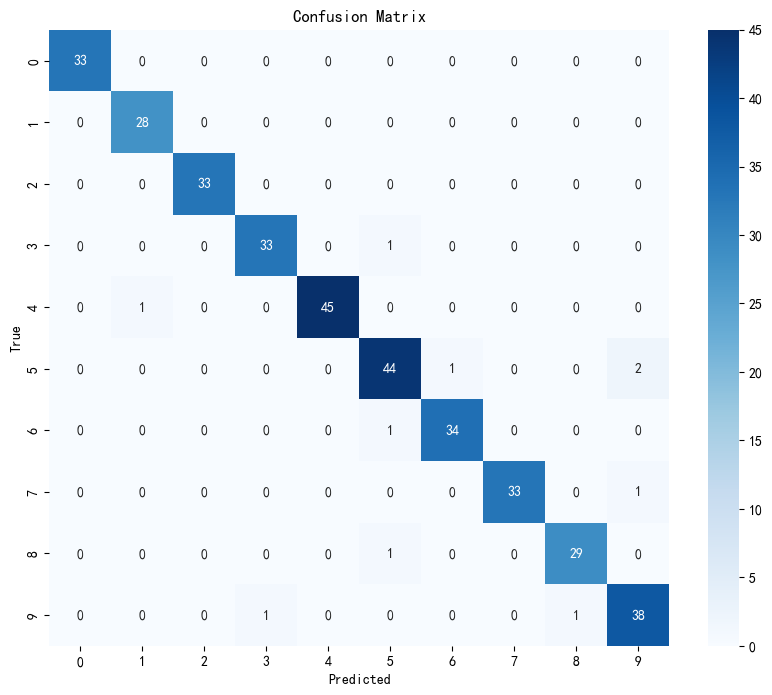


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       0.97      1.00      0.98        28
           2       1.00      1.00      1.00        33
           3       0.97      0.97      0.97        34
           4       1.00      0.98      0.99        46
           5       0.94      0.94      0.94        47
           6       0.97      0.97      0.97        35
           7       1.00      0.97      0.99        34
           8       0.97      0.97      0.97        30
           9       0.93      0.95      0.94        40

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360

SVM:
Accuracy: 0.9806


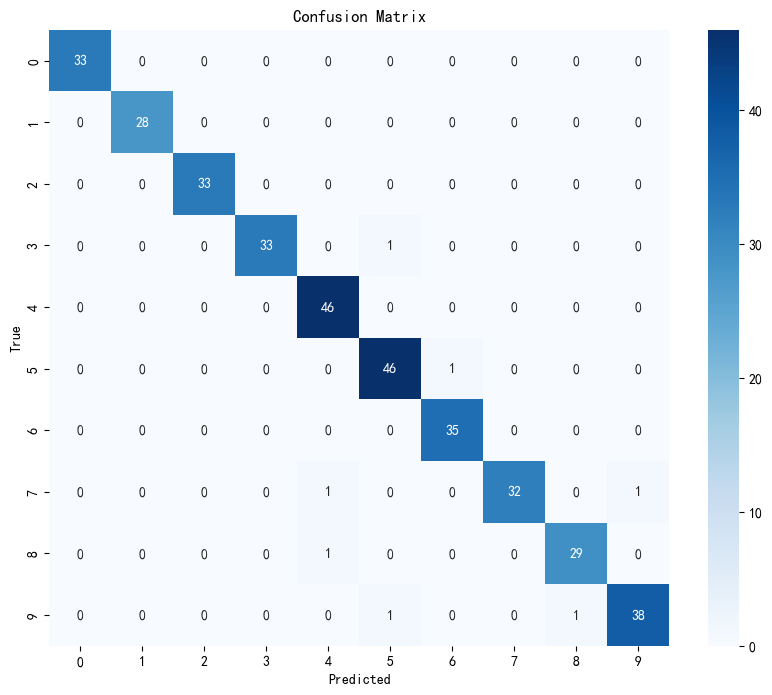


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        28
           2       1.00      1.00      1.00        33
           3       1.00      0.97      0.99        34
           4       0.96      1.00      0.98        46
           5       0.96      0.98      0.97        47
           6       0.97      1.00      0.99        35
           7       1.00      0.94      0.97        34
           8       0.97      0.97      0.97        30
           9       0.97      0.95      0.96        40

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360

Random Forest:
Accuracy: 0.9722


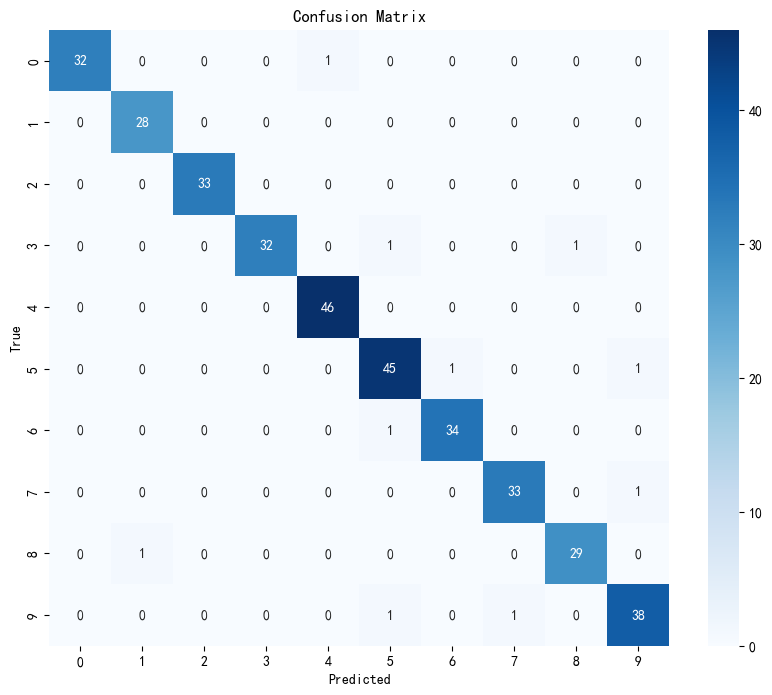


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98        33
           1       0.97      1.00      0.98        28
           2       1.00      1.00      1.00        33
           3       1.00      0.94      0.97        34
           4       0.98      1.00      0.99        46
           5       0.94      0.96      0.95        47
           6       0.97      0.97      0.97        35
           7       0.97      0.97      0.97        34
           8       0.97      0.97      0.97        30
           9       0.95      0.95      0.95        40

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360

自实现Softmax Regression:
Accuracy: 0.9333


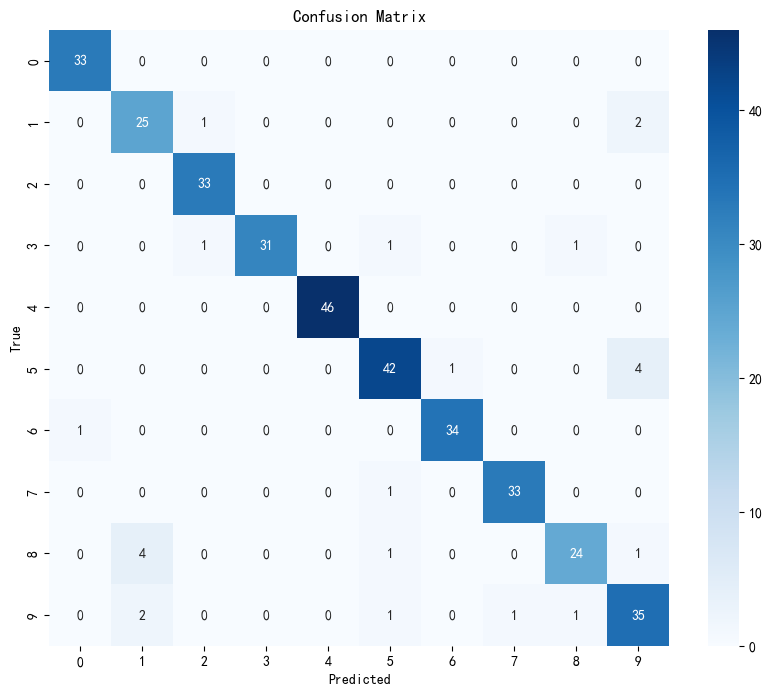


Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        33
           1       0.81      0.89      0.85        28
           2       0.94      1.00      0.97        33
           3       1.00      0.91      0.95        34
           4       1.00      1.00      1.00        46
           5       0.91      0.89      0.90        47
           6       0.97      0.97      0.97        35
           7       0.97      0.97      0.97        34
           8       0.92      0.80      0.86        30
           9       0.83      0.88      0.85        40

    accuracy                           0.93       360
   macro avg       0.93      0.93      0.93       360
weighted avg       0.94      0.93      0.93       360



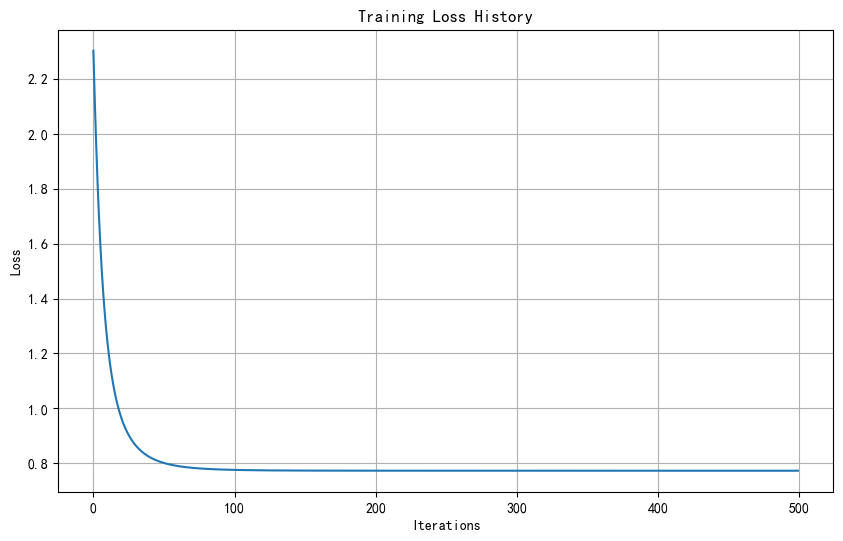

In [19]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression as SkLogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
# 指定支持中文的字体（如系统自带的 SimHei 或 Microsoft YaHei）
plt.rcParams['font.sans-serif'] = ['SimHei']  # Windows 系统
# plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']  # macOS
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
# 1. 高级优化算法
class LogisticRegression_Adam:
    def __init__(self, learning_rate=0.01, n_iters=1000, beta1=0.9, beta2=0.999, eps=1e-8, decay=0.0):
        self.lr = learning_rate
        self.n_iters = n_iters
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.decay = decay
        self.weights = None
        self.bias = None
        self.loss_history = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        m_w, v_w = np.zeros(n_features), np.zeros(n_features)
        m_b, v_b = 0, 0
        lr = self.lr
        for t in range(1, self.n_iters + 1):
            linear_model = np.dot(X, self.weights) + self.bias
            y_pred = self.sigmoid(linear_model)
            y_pred = np.clip(y_pred, 1e-8, 1 - 1e-8)
            loss = -np.mean(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))
            self.loss_history.append(loss)
            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)
            # Adam update
            m_w = self.beta1 * m_w + (1 - self.beta1) * dw
            v_w = self.beta2 * v_w + (1 - self.beta2) * (dw ** 2)
            m_b = self.beta1 * m_b + (1 - self.beta1) * db
            v_b = self.beta2 * v_b + (1 - self.beta2) * (db ** 2)
            m_w_hat = m_w / (1 - self.beta1 ** t)
            v_w_hat = v_w / (1 - self.beta2 ** t)
            m_b_hat = m_b / (1 - self.beta1 ** t)
            v_b_hat = v_b / (1 - self.beta2 ** t)
            self.weights -= lr * m_w_hat / (np.sqrt(v_w_hat) + self.eps)
            self.bias -= lr * m_b_hat / (np.sqrt(v_b_hat) + self.eps)
            # 学习率衰减
            lr = self.lr / (1 + self.decay * t)

    def predict(self, X, threshold=0.5):
        linear_model = np.dot(X, self.weights) + self.bias
        y_pred = self.sigmoid(linear_model)
        return (y_pred >= threshold).astype(int)

# SGD with learning rate decay
class LogisticRegression_SGD:
    def __init__(self, learning_rate=0.01, n_iters=1000, decay=0.0):
        self.lr = learning_rate
        self.n_iters = n_iters
        self.decay = decay
        self.weights = None
        self.bias = None
        self.loss_history = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        lr = self.lr
        for t in range(1, self.n_iters + 1):
            idx = np.random.randint(n_samples)
            xi = X[idx:idx+1]
            yi = y[idx:idx+1]
            linear_model = np.dot(xi, self.weights) + self.bias
            y_pred = self.sigmoid(linear_model)
            y_pred = np.clip(y_pred, 1e-8, 1 - 1e-8)
            loss = -np.mean(yi * np.log(y_pred) + (1 - yi) * np.log(1 - y_pred))
            self.loss_history.append(loss)
            dw = np.dot(xi.T, (y_pred - yi))
            db = np.sum(y_pred - yi)
            self.weights -= lr * dw.flatten()
            self.bias -= lr * db
            lr = self.lr / (1 + self.decay * t)

    def predict(self, X, threshold=0.5):
        linear_model = np.dot(X, self.weights) + self.bias
        y_pred = self.sigmoid(linear_model)
        return (y_pred >= threshold).astype(int)

# 训练并比较SGD和Adam
adam = LogisticRegression_Adam(learning_rate=0.01, n_iters=500, decay=0.001)
adam.fit(X_train, y_train_bin)
sgd = LogisticRegression_SGD(learning_rate=0.01, n_iters=500, decay=0.001)
sgd.fit(X_train, y_train_bin)

plt.figure(figsize=(8, 4))
plt.plot(adam.loss_history, label='Adam')
plt.plot(sgd.loss_history, label='SGD')
plt.title('Loss Curve: Adam vs SGD (with LR decay)')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

print("Adam Optimizer:")
evaluate_model(adam, X_test, y_test_bin)
print("SGD Optimizer:")
evaluate_model(sgd, X_test, y_test_bin)

# 2. 特征工程实验
# 归一化
minmax_scaler = MinMaxScaler()
X_minmax = minmax_scaler.fit_transform(X)
X_train_minmax, X_test_minmax, _, _ = train_test_split(X_minmax, y, test_size=0.2, random_state=42)

# PCA降维
pca = PCA(n_components=20)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# 用PCA降维后的特征训练Softmax回归
softmax_pca = SoftmaxRegression(learning_rate=0.1, n_iters=500, lambda_=0.1)
softmax_pca.fit(X_train_pca, y_train)
print("Softmax Regression with PCA (20 dims):")
evaluate_model(softmax_pca, X_test_pca, y_test)

# 用归一化特征训练Softmax回归
softmax_minmax = SoftmaxRegression(learning_rate=0.1, n_iters=500, lambda_=0.1)
softmax_minmax.fit(X_train_minmax, y_train)
print("Softmax Regression with MinMax Scaling:")
evaluate_model(softmax_minmax, X_test_minmax, y_test)

# 3. 多模型对比
# sklearn LogisticRegression
sk_logreg = SkLogisticRegression(max_iter=1000, solver='lbfgs', multi_class='multinomial')
sk_logreg.fit(X_train, y_train)
print("scikit-learn LogisticRegression:")
evaluate_model(sk_logreg, X_test, y_test)

# SVM
svm = SVC()
svm.fit(X_train, y_train)
print("SVM:")
evaluate_model(svm, X_test, y_test)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
print("Random Forest:")
evaluate_model(rf, X_test, y_test)

# 性能对比总结
print("自实现Softmax Regression:")
evaluate_model(best_softmax, X_test, y_test)

1. **为什么逻辑回归使用交叉熵损失而不是均方误差损失？**  
    - 交叉熵损失（对数损失）与概率建模和极大似然估计原理一致，能更好地度量模型输出概率与真实标签的差异。均方误差不适合概率输出，容易导致梯度消失，影响收敛速度和效果。

2. **Softmax函数中为什么要进行数值稳定性处理（减去最大值）？**  
    - Softmax 的指数运算容易导致数值溢出或下溢。减去每行最大值不会改变输出，但能有效避免 exp 溢出，提高计算稳定性。

3. **如何解释L2正则化对模型权重的影响？**  
    - L2正则化通过在损失函数中加入权重平方和，抑制权重过大，防止过拟合，使模型更简单、更具泛化能力。

4. **当类别数量极不平衡时，逻辑回归模型可能遇到什么问题？如何解决？**  
    - 问题：模型倾向于预测多数类，导致少数类召回率低。  
    - 解决方法：可采用类别权重调整、过采样/欠采样、SMOTE等方法，或使用更适合不平衡数据的评价指标（如AUC、F1分数）。

5. **为什么多分类问题中Softmax回归比多个二分类逻辑回归组合更优？**  
    - Softmax回归直接建模多类概率分布，输出归一化概率，能捕捉类别间的相互排斥关系。多个二分类模型（如一对多）输出概率不归一，类别间独立，可能出现多个类别同时被预测为正例，解释性和概率一致性较差。

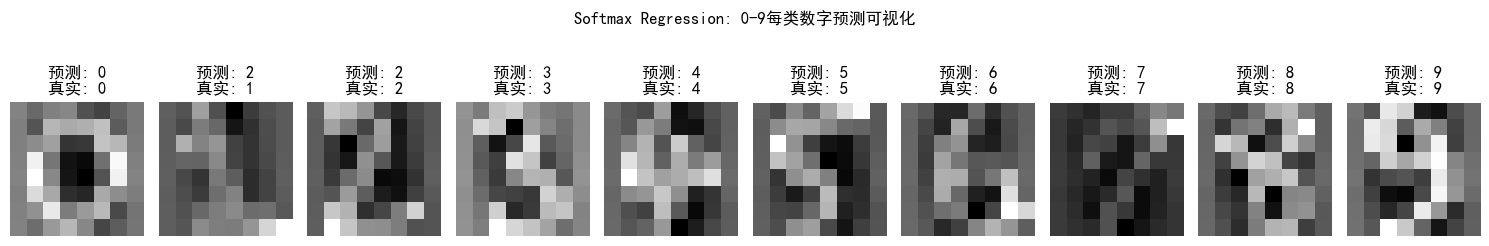

In [20]:
# 使用自实现Softmax回归模型对MNIST 0-9数字进行多分类，并可视化每个数字的预测结果

# 对于每个数字0-9，找出其在测试集中的第一个样本进行可视化
fig, axes = plt.subplots(1, 10, figsize=(15, 3))
for digit in range(10):
    # 找到y_test中等于digit的第一个索引
    idx = np.where(y_test == digit)[0][0]
    image = X_test[idx].reshape(8, 8)
    pred = best_softmax.predict(X_test[idx:idx+1])[0]
    axes[digit].imshow(image, cmap='gray')
    axes[digit].set_title(f"预测: {pred}\n真实: {digit}")
    axes[digit].axis('off')
plt.suptitle("Softmax Regression: 0-9每类数字预测可视化")
plt.tight_layout()
plt.show()

数字0识别准确率: 0.9972222222222222
整体分类准确率: 0.9694444444444444
混淆矩阵:
 [[27  0  0  0  0  0  0  0  0  0]
 [ 0 34  0  0  0  0  0  0  1  0]
 [ 0  0 35  1  0  0  0  0  0  0]
 [ 0  0  0 29  0  0  0  0  0  0]
 [ 0  0  0  0 29  0  0  1  0  0]
 [ 0  0  0  0  0 38  0  0  0  2]
 [ 0  1  0  0  0  0 43  0  0  0]
 [ 0  0  0  0  1  0  0 38  0  0]
 [ 0  2  1  0  0  0  0  0 36  0]
 [ 0  0  0  0  0  1  0  0  0 40]]


d:\software\Miniconda\miniconda3\envs\machine_learning\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


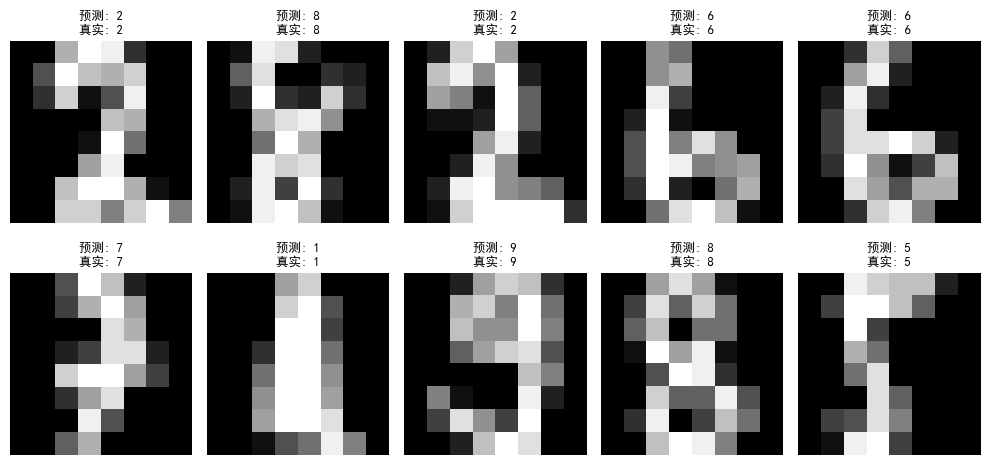

In [24]:
from sklearn.datasets import load_digits
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

# 1. 数据加载与预处理
digits = load_digits()
X = digits.data
y = digits.target

# 划分训练集和测试集 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# 2. 逻辑回归二分类（识别数字0）
y_train_0 = (y_train == 0).astype(int)
y_test_0 = (y_test == 0).astype(int)

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train_0)

# 评估二分类模型
y_pred_0 = log_reg.predict(X_test)
print("数字0识别准确率:", accuracy_score(y_test_0, y_pred_0))

# 3. Softmax回归多分类（识别0-9）
softmax_reg = LogisticRegression(
    multi_class='multinomial', 
    solver='lbfgs', 
    max_iter=1000  
)
softmax_reg.fit(X_train, y_train)

# 评估多分类模型
y_pred = softmax_reg.predict(X_test)
print("整体分类准确率:", accuracy_score(y_test, y_pred))
print("混淆矩阵:\n", confusion_matrix(y_test, y_pred))

# 4. 可视化预测结果
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i].reshape(8, 8), cmap='gray', interpolation='nearest')
    ax.set_title(f"预测: {y_pred[i]}\n真实: {y_test[i]}", fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()